In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [22]:
# ============================================================================
# CHARGEMENT DES DONNÉES
# ============================================================================

print("="*80)
print("📁 EXPLORATION DES DONNÉES - features_comptes.xlsx")
print("="*80)

# Charger le fichier
df = pd.read_excel(r"C:\Users\Pc\Desktop\new\opérations comptes.xls", engine='xlrd')

print(f"\n✓ Données chargées avec succès")
print(f"  Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")

# ============================================================================
# 1. APERÇU GÉNÉRAL
# ============================================================================

print("\n" + "="*80)
print("1. APERÇU GÉNÉRAL DES DONNÉES")
print("="*80)

print("\n📋 Premières lignes:")
print(df.head(10))

print("\n📊 Informations sur les colonnes:")
df.info()

📁 EXPLORATION DES DONNÉES - features_comptes.xlsx

✓ Données chargées avec succès
  Dimensions: 11309 lignes × 10 colonnes

1. APERÇU GÉNÉRAL DES DONNÉES

📋 Premières lignes:
   numero poece identite                compte   montant sens operation  \
0                 4905.0  14010123119700000768  5969.000              C   
1                 3445.0  14010123110716486824  5000.000              D   
2                 4222.0  14010123110726899712   200.000              D   
3                  967.0  14010123110700081311   405.000              D   
4                 1626.0  14010123110719634183  1000.000              D   
5                 1285.0  14010123110705600512   300.000              D   
6                 1071.0  14010123110741711771    20.000              D   
7                  985.0  14010123110719989106   270.000              D   
8                  705.0  14010123110725799936    11.700              D   
9                 2922.0  14010123110715637589    55.841              D   


In [23]:
# ============================================================================
# 2. TYPES DE DONNÉES
# ============================================================================

print("\n" + "="*80)
print("2. TYPES DE DONNÉES")
print("="*80)

print("\n📊 Répartition par type:")
print(df.dtypes.value_counts())

print("\n📝 Détail par colonne:")
for col in df.columns:
    dtype = df[col].dtype
    n_unique = df[col].nunique()
    print(f"  {col:30s} → {str(dtype):10s} ({n_unique:,} valeurs uniques)")



2. TYPES DE DONNÉES

📊 Répartition par type:
object     6
float64    4
Name: count, dtype: int64

📝 Détail par colonne:
  numero poece identite          → float64    (4,990 valeurs uniques)
  compte                         → object     (2,839 valeurs uniques)
  montant                        → float64    (3,218 valeurs uniques)
  sens operation                 → object     (2 valeurs uniques)
  ID_transaction                 → object     (8,941 valeurs uniques)
  motif operation                → object     (593 valeurs uniques)
  agence                         → float64    (1 valeurs uniques)
  Lieu                           → object     (25 valeurs uniques)
  date_operation                 → object     (10,920 valeurs uniques)
  anomalie                       → float64    (2 valeurs uniques)


In [24]:
# ============================================================================
# 3. STATISTIQUES DESCRIPTIVES
# ============================================================================

print("\n" + "="*80)
print("3. STATISTIQUES DESCRIPTIVES")
print("="*80)

# Séparer numériques et catégorielles
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n Colonnes numériques: {len(numeric_cols)}")
print(f" Colonnes catégorielles: {len(categorical_cols)}")

print("\nStatistiques des colonnes numériques:")
print(df[numeric_cols].describe().T)

if len(categorical_cols) > 0:
    print("\ Statistiques des colonnes catégorielles:")
    for col in categorical_cols:
        print(f"\n  {col}:")
        print(f"    Valeurs uniques: {df[col].nunique()}")
        print(f"    Top 5 valeurs:")
        print(df[col].value_counts().head(5))


3. STATISTIQUES DESCRIPTIVES

 Colonnes numériques: 4
 Colonnes catégorielles: 6

Statistiques des colonnes numériques:
                         count         mean          std  min     25%     50%  \
numero poece identite  11005.0  2820.396910  1610.717915  1.0  1407.0  2846.0   
montant                11005.0   713.103333  5100.819522  5.0    48.0   107.0   
agence                 11005.0     0.000000     0.000000  0.0     0.0     0.0   
anomalie               11005.0     0.158746     0.365456  0.0     0.0     0.0   

                          75%       max  
numero poece identite  4307.0    5207.0  
montant                 400.0  200000.0  
agence                    0.0       0.0  
anomalie                  0.0       1.0  
\ Statistiques des colonnes catégorielles:

  compte:
    Valeurs uniques: 2839
    Top 5 valeurs:
compte
                        304
14010123110700011651     37
14010123110800890123     36
14010123110746927073     36
14010123110700779032     31
Name: count, dtyp

<>:20: SyntaxWarning: invalid escape sequence '\ '
<>:20: SyntaxWarning: invalid escape sequence '\ '
C:\Users\Pc\AppData\Local\Temp\ipykernel_23904\2122926839.py:20: SyntaxWarning: invalid escape sequence '\ '
  print("\ Statistiques des colonnes catégorielles:")


In [25]:
# ============================================================================
# 4. VALEURS MANQUANTES
# ============================================================================

print("\n" + "="*80)
print("4. ANALYSE DES VALEURS MANQUANTES")
print("="*80)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Colonne': missing.index,
    'Nb_Manquantes': missing.values,
    'Pct_Manquantes': missing_pct.values
})
missing_df = missing_df[missing_df['Nb_Manquantes'] > 0].sort_values('Nb_Manquantes', ascending=False)

if len(missing_df) > 0:
    print(f"\n⚠  {len(missing_df)} colonnes avec valeurs manquantes:\n")
    print(missing_df.to_string(index=False))
    
    print(f"\nTotal de valeurs manquantes: {missing.sum():,}")
    print(f" Pourcentage global: {(missing.sum() / df.size * 100):.2f}%")
else:
    print("\nAucune valeur manquante détectée!")


4. ANALYSE DES VALEURS MANQUANTES

⚠  9 colonnes avec valeurs manquantes:

              Colonne  Nb_Manquantes  Pct_Manquantes
numero poece identite            304        2.688125
              montant            304        2.688125
       sens operation            304        2.688125
       ID_transaction            304        2.688125
      motif operation            304        2.688125
               agence            304        2.688125
                 Lieu            304        2.688125
       date_operation            304        2.688125
             anomalie            304        2.688125

Total de valeurs manquantes: 2,736
 Pourcentage global: 2.42%


In [26]:
# ============================================================================
# 5. VALEURS DUPLIQUÉES
# ============================================================================

print("\n" + "="*80)
print("5. ANALYSE DES DOUBLONS")
print("="*80)

duplicates = df.duplicated().sum()
print(f"\n Lignes en double: {duplicates}")

if duplicates > 0:
    print(f"⚠  {duplicates} doublons détectés ({duplicates/len(df)*100:.2f}%)")
    print("\nExemples de doublons:")
    print(df[df.duplicated(keep=False)].head(10))
else:
    print(" Aucun doublon détecté!")


5. ANALYSE DES DOUBLONS

 Lignes en double: 303
⚠  303 doublons détectés (2.68%)

Exemples de doublons:
       numero poece identite compte  montant sens operation ID_transaction  \
11005                    NaN             NaN            NaN            NaN   
11006                    NaN             NaN            NaN            NaN   
11007                    NaN             NaN            NaN            NaN   
11008                    NaN             NaN            NaN            NaN   
11009                    NaN             NaN            NaN            NaN   
11010                    NaN             NaN            NaN            NaN   
11011                    NaN             NaN            NaN            NaN   
11012                    NaN             NaN            NaN            NaN   
11013                    NaN             NaN            NaN            NaN   
11014                    NaN             NaN            NaN            NaN   

      motif operation  agence Lieu d

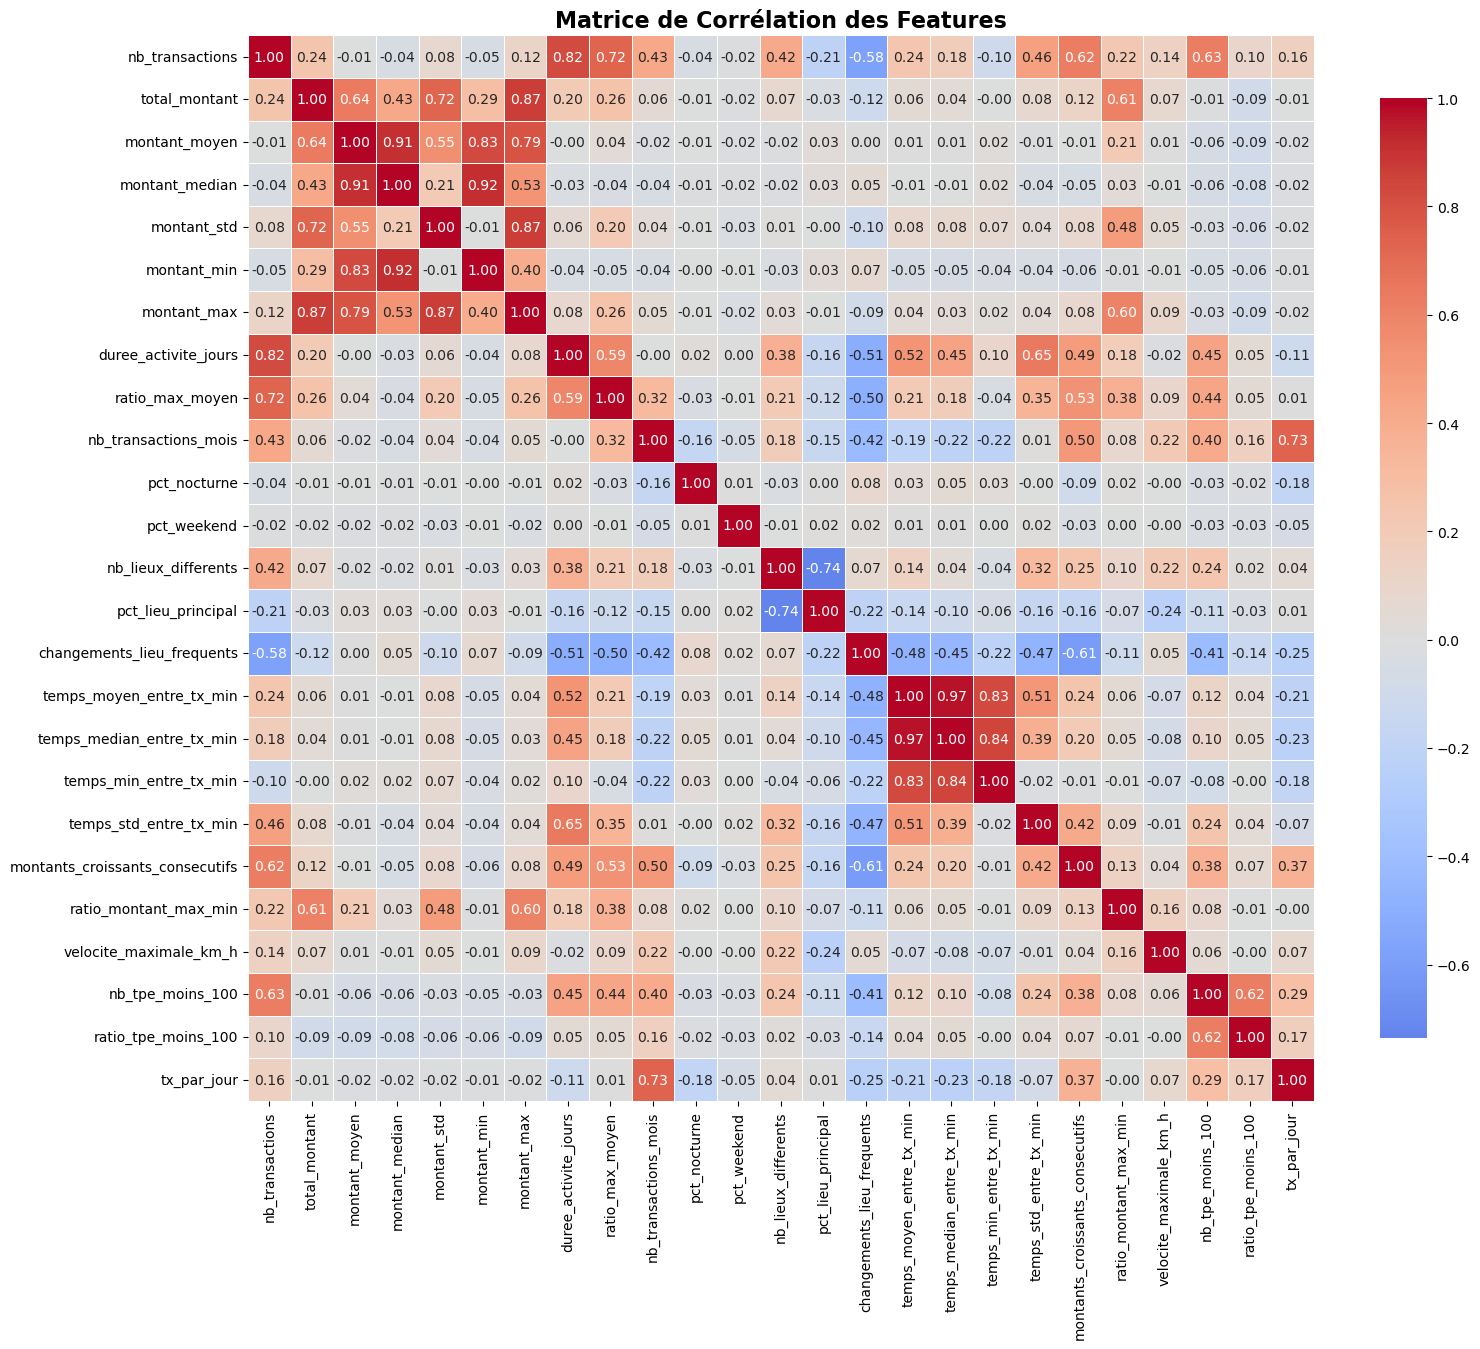

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
df = pd.read_excel(r"C:\Users\Pc\Desktop\new\features_comptes.xlsx", engine='openpyxl')

# Sélectionner colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number]).drop('compte', axis=1, errors='ignore').columns

# ============================================================================
# 1. MATRICE DE CORRÉLATION
# ============================================================================

plt.figure(figsize=(16, 14))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Corrélation des Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

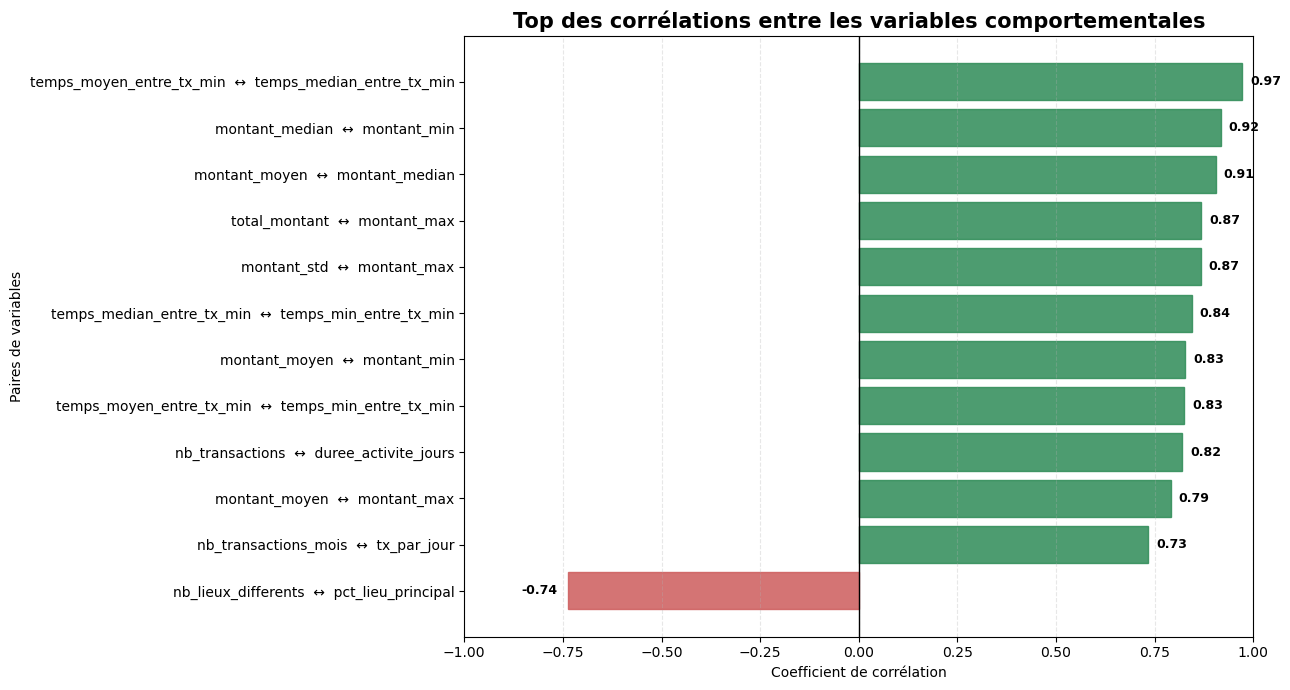

In [9]:
 # ============================================================================
# 4. TOP CORRÉLATIONS — VERSION AMÉLIORÉE
# ============================================================================

corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_pairs.append({
            'var1': corr_matrix.columns[i],
            'var2': corr_matrix.columns[j],
            'correlation': corr_matrix.iloc[i, j]
        })

corr_df = (
    pd.DataFrame(corr_pairs)
    .sort_values('correlation', key=abs, ascending=False)
    .head(12)
)

# Labels plus lisibles
corr_df["label"] = corr_df.apply(
    lambda x: f"{x['var1']}  ↔  {x['var2']}",
    axis=1
)

# Tri pour affichage propre
corr_df = corr_df.sort_values("correlation")

plt.figure(figsize=(13, 7))

bars = plt.barh(
    corr_df["label"],
    corr_df["correlation"],
    edgecolor='black',
    alpha=0.85
)

# Couleurs positives / négatives
for bar, val in zip(bars, corr_df["correlation"]):
    if val >= 0:
        bar.set_color("#2E8B57")  # vert
    else:
        bar.set_color("#CD5C5C")  # rouge

# Valeurs sur les barres
for i, val in enumerate(corr_df["correlation"]):
    plt.text(
        val + (0.02 if val >= 0 else -0.12),
        i,
        f"{val:.2f}",
        va='center',
        fontsize=9,
        fontweight='bold'
    )

plt.axvline(0, color='black', linewidth=1)

plt.title(
    "Top des corrélations entre les variables comportementales",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Coefficient de corrélation")
plt.ylabel("Paires de variables")

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.xlim(-1, 1)

plt.tight_layout()
plt.show()

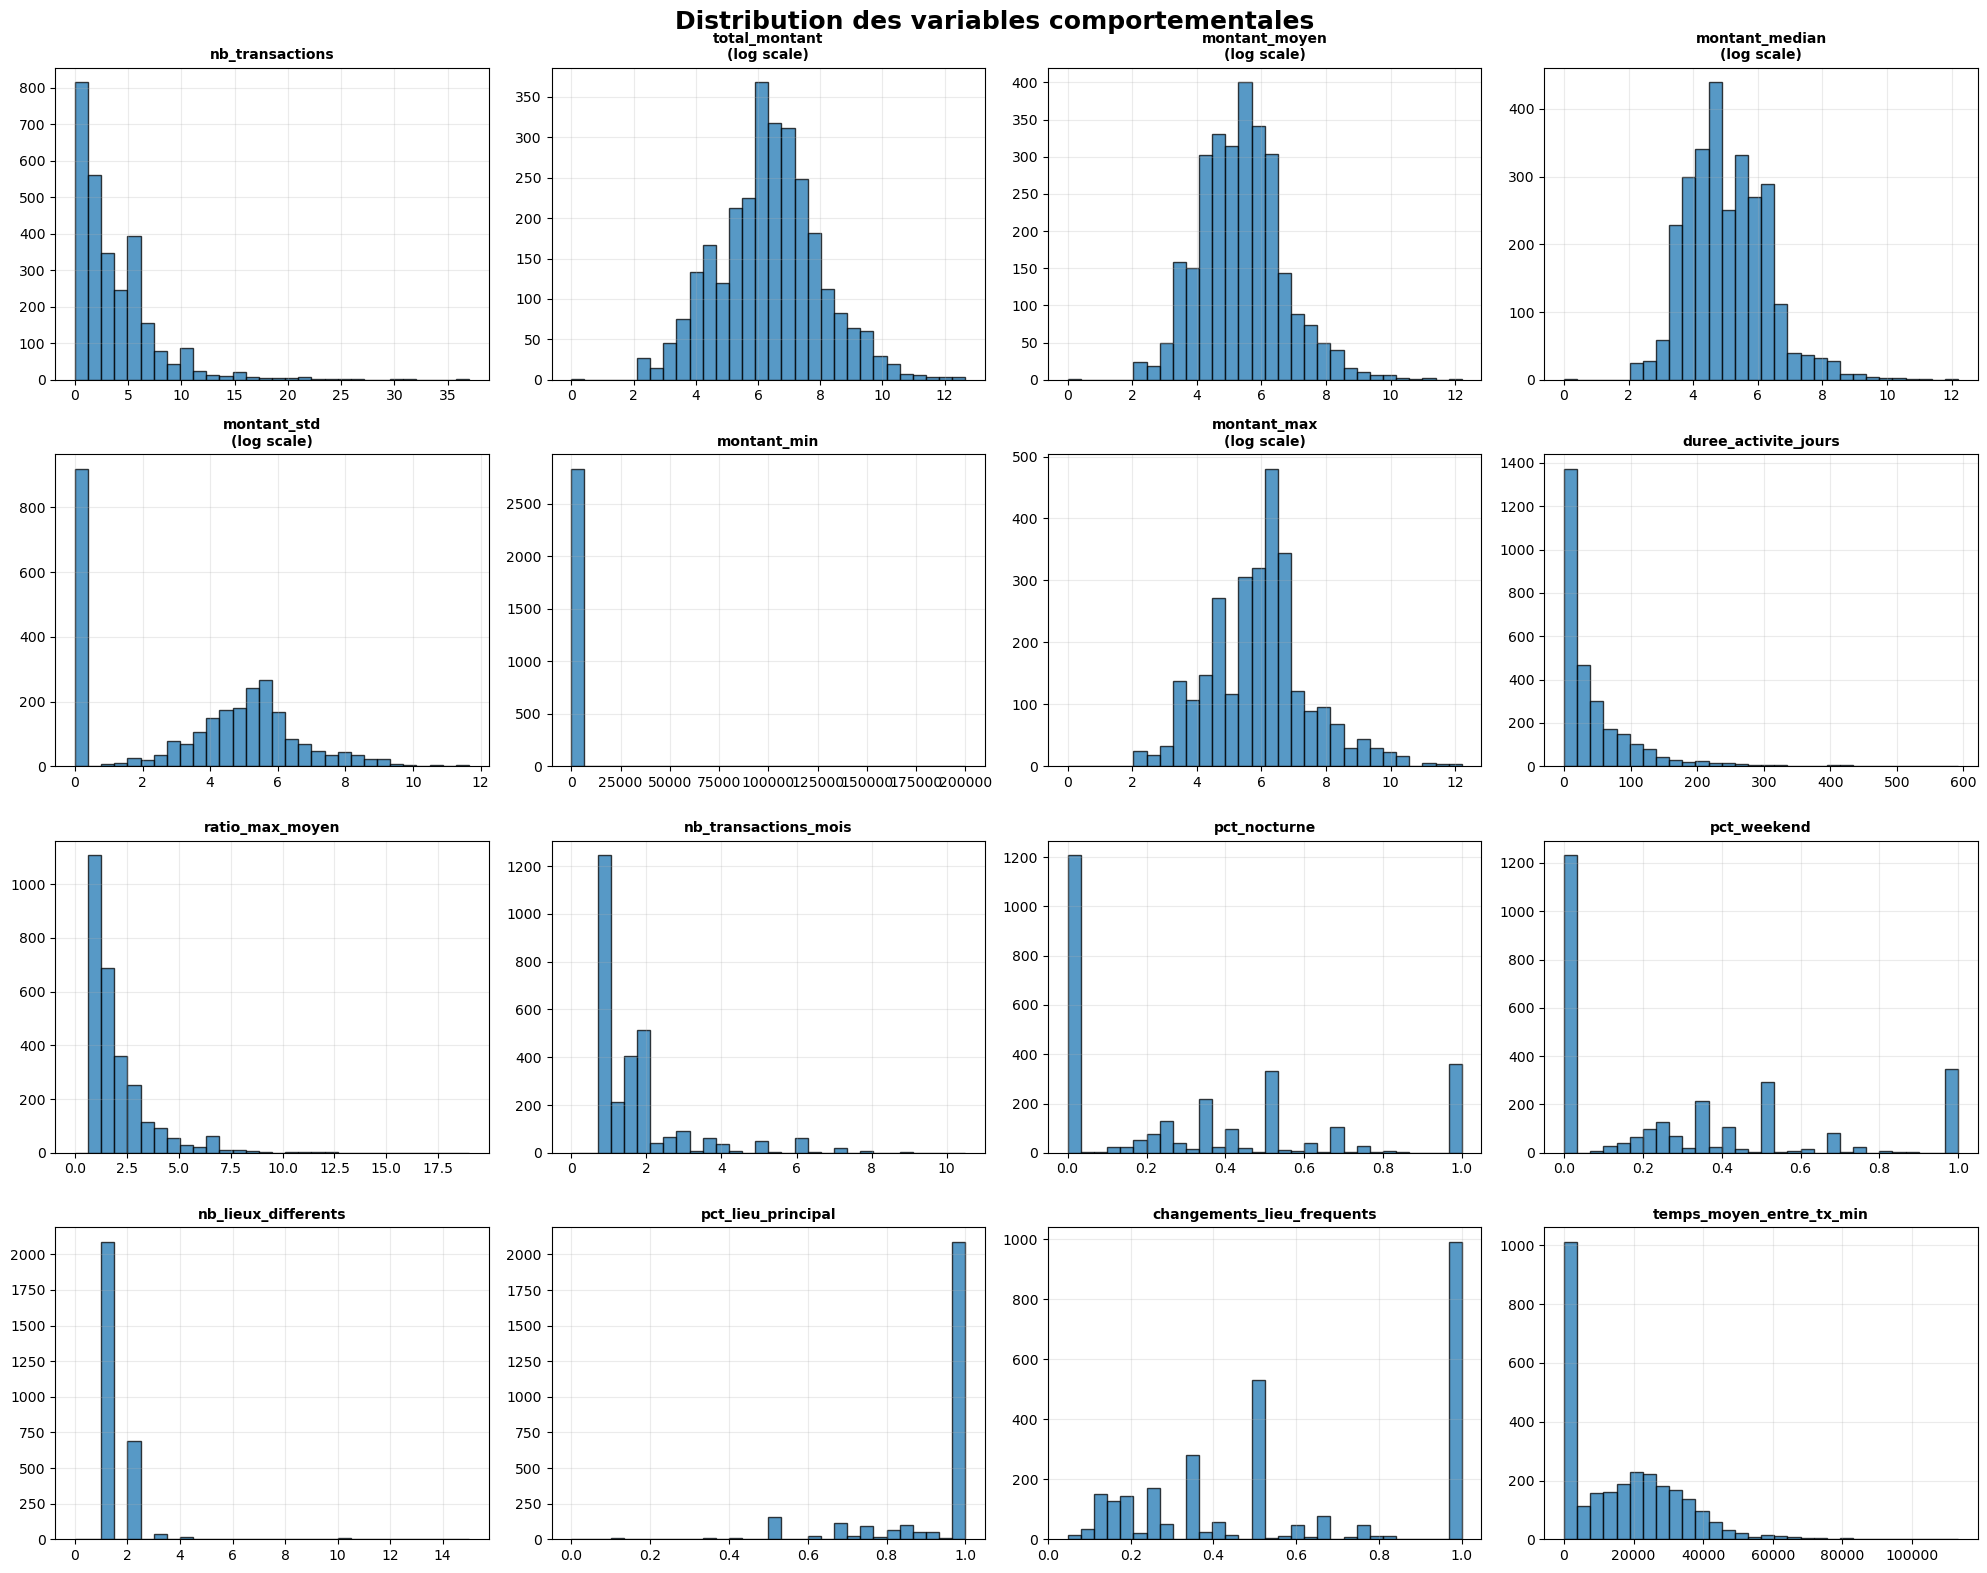

In [8]:
# ============================================================================
# DISTRIBUTIONS DES VARIABLES — VERSION AMÉLIORÉE
# ============================================================================

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

# Variables à transformer en log
log_vars = [
    'total_montant',
    'montant_moyen',
    'montant_median',
    'montant_std',
    'montant_max'
]

for idx, col in enumerate(numeric_cols[:16]):

    data = df[col].dropna()

    # Transformation log pour grosses valeurs
    if col in log_vars:
        data = np.log1p(data)
        titre = f"{col}\n(log scale)"
    else:
        titre = col

    axes[idx].hist(
        data,
        bins=30,
        edgecolor='black',
        alpha=0.75
    )

    axes[idx].set_title(
        titre,
        fontsize=10,
        fontweight='bold'
    )

    axes[idx].grid(True, alpha=0.25)

plt.suptitle(
    "Distribution des variables comportementales",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

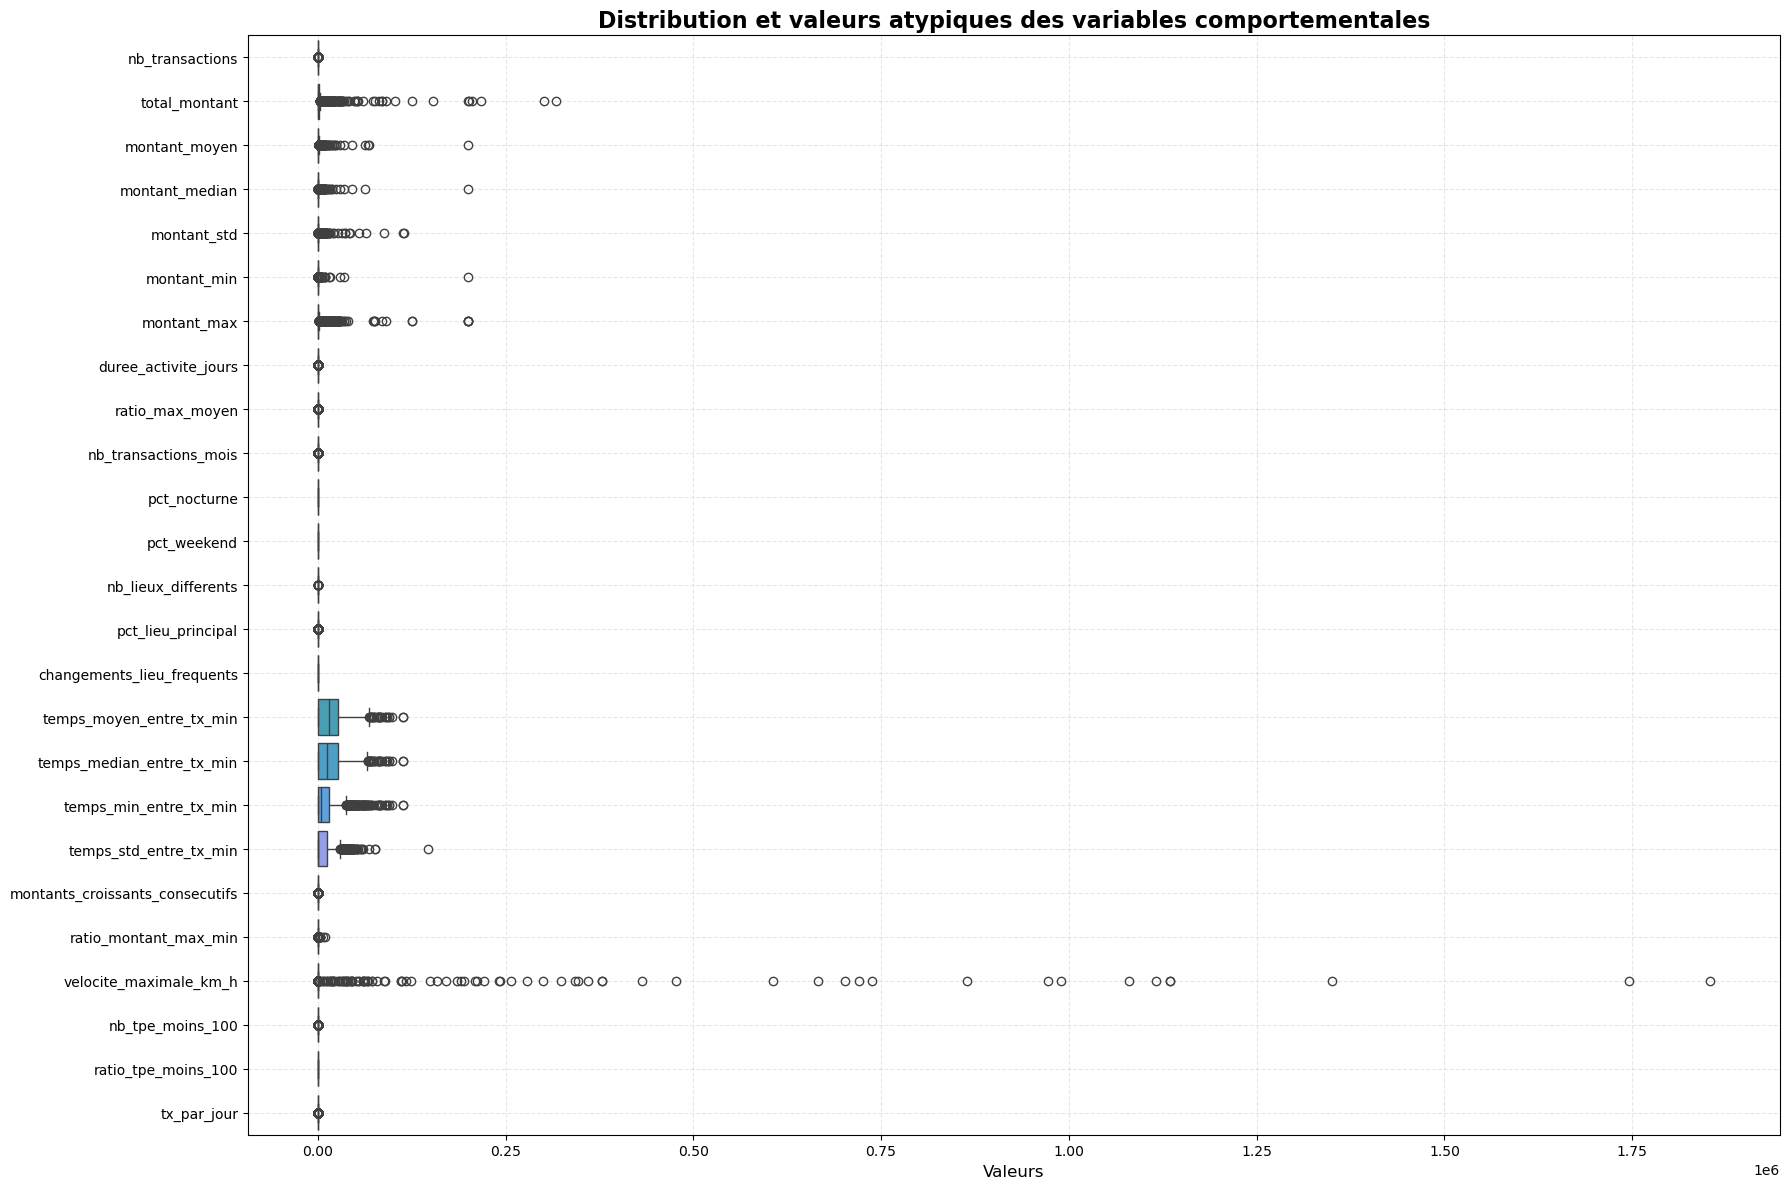

In [15]:
# ============================================================================
# BOXPLOTS — TOUTES LES VARIABLES NUMÉRIQUES
# ============================================================================

# Sélection des colonnes numériques
all_numeric_vars = df.select_dtypes(
    include=[np.number]
).drop(
    columns=['compte'],
    errors='ignore'
)

plt.figure(figsize=(18, 12))

sns.boxplot(
    data=all_numeric_vars,
    orient='h'
)

plt.title(
    "Distribution et valeurs atypiques des variables comportementales",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Valeurs", fontsize=12)

plt.grid(
    alpha=0.3,
    linestyle='--'
)

plt.tight_layout()

plt.show()